In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

master_data = pd.read_csv("/content/Student Stress Assessment Updated.csv")
master_data.head()

,Age,Gender,Marital status,Current primary role,Highest level of education,Stream/Decipline,Type of institution,Living arrangement,Do you currently earn an income?,Approximate monthly household income,...,V9,V10,V11,V12,V13,V14,V15,V16,V17,Target
0,18-24,Male,Single,Student,Undergraduate,Arts / Humanities,Government / Public,With family,No,Prefer not to say,...,5,5,5,5,3,5,3,4,1,2
1,18-24,Female,Single,Employed (full-time),Undergraduate,Commerce / Management,Private,With family,Yes,"Below ₹20,000",...,4,4,4,3,4,4,3,4,4,2
2,25-34,Female,Married,Employed (full-time),Postgraduate,Engineering / Technology,Private,With family,Yes,"₹50,001–₹1,00,000",...,4,4,4,2,4,4,4,4,4,2
3,25-34,Female,Single,Employed (full-time),Postgraduate,Commerce / Management,Private,With family,Yes,"₹20,000–₹50,000",...,4,4,4,4,4,4,3,3,4,2
4,35-44,Female,Married,Employed (full-time),Postgraduate,Commerce / Management,Private,With family,Yes,"Above ₹1,00,000",...,5,5,5,3,4,2,2,4,5,3


In [ ]:
df_x = master_data.iloc[:,10:27]

In [ ]:
df_x.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17
0,3,4,2,3,4,2,4,1,5,5,5,5,3,5,3,4,1
1,3,4,4,3,3,4,2,4,4,4,4,3,4,4,3,4,4
2,2,4,2,4,4,2,4,2,4,4,4,2,4,4,4,4,4
3,1,3,1,2,2,3,3,4,4,4,4,4,4,4,3,3,4
4,4,4,4,4,5,2,4,4,5,5,5,3,4,2,2,4,5


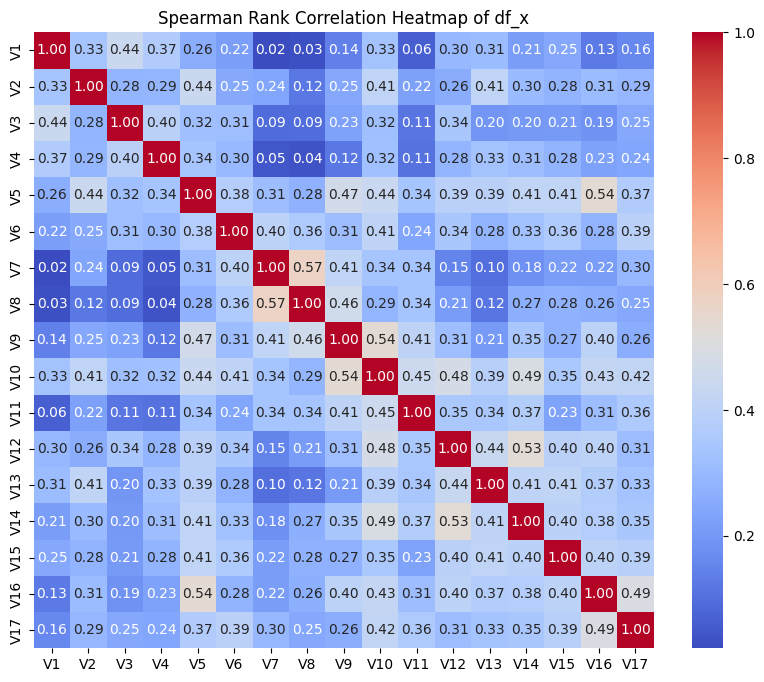

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

spearman_corr = df_x.corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Spearman Rank Correlation Heatmap of df_x')
plt.show()

In [ ]:
df_y = master_data['Target']
df_y.head()

,Target
0,2
1,2
2,2
3,2
4,3


In [ ]:
!pip install pingouin

In [ ]:
import pingouin as pg

# Perform Cronbach's Alpha test on df_x
cronbach_alpha_result = pg.cronbach_alpha(data=df_x)

print(f"Cronbach's Alpha for df_x: {cronbach_alpha_result[0]:.4f}")

Cronbach's Alpha for df_x: 0.8895


**Descriptive Analysis**

In [ ]:
master_data.describe(include = 'O')

,Age,Gender,Marital status,Current primary role,Highest level of education,Stream/Decipline,Type of institution,Living arrangement,Do you currently earn an income?,Approximate monthly household income
count,220,220,220,220,220,220,220,220,220,220
unique,5,2,4,5,3,6,3,4,2,5
top,18-24,Male,Single,Student,Undergraduate,Commerce / Management,Private,With family,No,Prefer not to say
freq,196,115,211,196,124,89,155,158,184,78


In [ ]:
from scipy.stats import f_oneway
import pandas as pd

# Group the 'Target' variable by 'Living arrangement'
groups = master_data.groupby('Living arrangement')['Target'].apply(list)

# Perform ANOVA if there are at least two groups
if len(groups) >= 2:
    # Extract lists of 'Target' values for each group
    group_data = [group for group in groups]

    # Perform one-way ANOVA
    f_statistic, p_value = f_oneway(*group_data)

    print(f"ANOVA Results for 'Target' by 'Living arrangement':\n")
    print(f"F-statistic: {f_statistic:.4f}")
    print(f"P-value: {p_value:.4f}")

    alpha = 0.05 # Significance level

    if p_value < alpha:
        print("\nSince the p-value is less than the significance level (alpha = 0.05), we reject the null hypothesis.")
        print("There is a statistically significant difference in the mean 'Target' across different 'Living arrangement' groups.")
    else:
        print("\nSince the p-value is greater than the significance level (alpha = 0.05), we fail to reject the null hypothesis.")
        print("There is no statistically significant difference in the mean 'Target' across different 'Living arrangement' groups.")
else:
    print("Not enough groups in 'Living arrangement' to perform ANOVA.")

ANOVA Results for 'Target' by 'Living arrangement':

F-statistic: 4.0898
P-value: 0.0075

Since the p-value is less than the significance level (alpha = 0.05), we reject the null hypothesis.
There is a statistically significant difference in the mean 'Target' across different 'Living arrangement' groups.


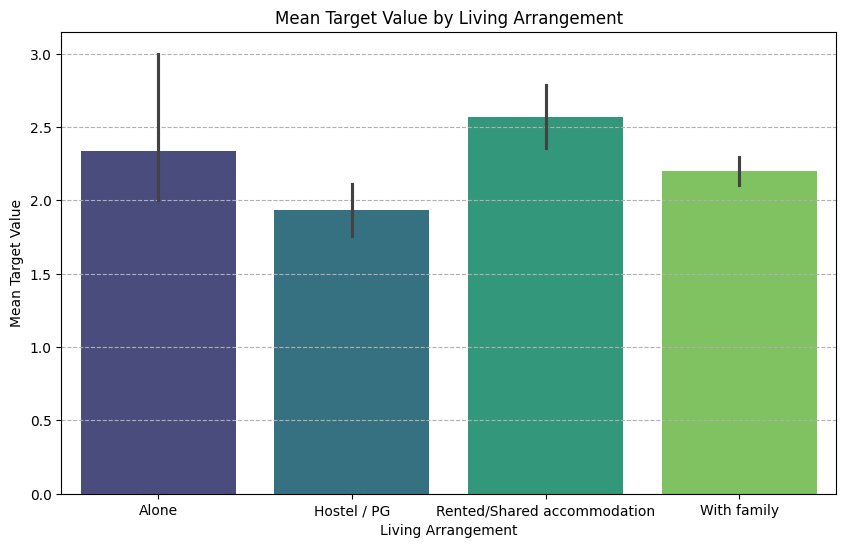

<Figure size 640x480 with 0 Axes>

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Assuming 'groups' contains the 'Target' values grouped by '  Living arrangement'
# (as generated in the previous ANOVA cell)

# Create a DataFrame from the 'groups' Series for easier plotting
plot_data = groups.reset_index()
plot_data = plot_data.explode('Target')
plot_data['Target'] = plot_data['Target'].astype(int) # Ensure Target is numeric

plt.figure(figsize=(10, 6))
sns.barplot(x='Living arrangement', y='Target', data=plot_data, palette='viridis')
plt.title('Mean Target Value by Living Arrangement')
plt.xlabel('Living Arrangement')
plt.ylabel('Mean Target Value')
plt.grid(axis='y', linestyle='--')
plt.show()
plt.savefig("my_plot.png", dpi=300)

In [ ]:
from scipy import stats
import pandas as pd

# Get unique values for 'Gender' to ensure it's binary
unique_genders = master_data['Gender'].unique()
print(f"Unique genders in the dataset: {unique_genders}")

if len(unique_genders) == 2:
    # Separate 'Target' values for each gender
    gender_group1 = master_data[master_data['Gender'] == unique_genders[0]]['Target']
    gender_group2 = master_data[master_data['Gender'] == unique_genders[1]]['Target']

    # Perform independent samples t-test
    t_statistic, p_value = stats.ttest_ind(gender_group1, gender_group2, equal_var=False) # Welch's t-test, assuming unequal variances

    print(f"\nT-test Results for 'Target' by 'Gender':")
    print(f"Group 1 ({unique_genders[0]}) count: {len(gender_group1)}")
    print(f"Group 2 ({unique_genders[1]}) count: {len(gender_group2)}")
    print(f"T-statistic: {t_statistic:.4f}")
    print(f"P-value: {p_value:.4f}")

    alpha = 0.05 # Significance level

    if p_value < alpha:
        print(f"\nSince the p-value ({p_value:.4f}) is less than the significance level (alpha = {alpha}), we reject the null hypothesis.")
        print(f"There is a statistically significant difference in the mean 'Target' between {unique_genders[0]} and {unique_genders[1]}.")
    else:
        print(f"\nSince the p-value ({p_value:.4f}) is greater than the significance level (alpha = {alpha}), we fail to reject the null hypothesis.")
        print(f"There is no statistically significant difference in the mean 'Target' between {unique_genders[0]} and {unique_genders[1]}.")
elif len(unique_genders) > 2:
    print("More than two unique genders found. Please consider ANOVA or post-hoc tests for multiple group comparisons.")
else:
    print("Not enough unique genders to perform a T-test (less than 2). ")

Unique genders in the dataset: ['Male' 'Female']

T-test Results for 'Target' by 'Gender':
Group 1 (Male) count: 115
Group 2 (Female) count: 105
T-statistic: 0.2349
P-value: 0.8145

Since the p-value (0.8145) is greater than the significance level (alpha = 0.05), we fail to reject the null hypothesis.
There is no statistically significant difference in the mean 'Target' between Male and Female.


In [ ]:
from scipy.stats import f_oneway
import pandas as pd

# Group the 'Target' variable by '  Approximate monthly household income'
income_groups = master_data.groupby('  Approximate monthly household income')['Target'].apply(list)

# Perform ANOVA if there are at least two groups
if len(income_groups) >= 2:
    # Extract lists of 'Target' values for each group
    group_data_income = [group for group in income_groups]

    # Perform one-way ANOVA
    f_statistic_income, p_value_income = f_oneway(*group_data_income)

    print(f"ANOVA Results for 'Target' by 'Approximate monthly household income':\n")
    print(f"F-statistic: {f_statistic_income:.4f}")
    print(f"P-value: {p_value_income:.4f}")

    alpha = 0.05 # Significance level

    if p_value_income < alpha:
        print("\nSince the p-value is less than the significance level (alpha = 0.05), we reject the null hypothesis.")
        print("There is a statistically significant difference in the mean 'Target' across different 'Approximate monthly household income' groups.")
    else:
        print("\nSince the p-value is greater than the significance level (alpha = 0.05), we fail to reject the null hypothesis.")
        print("There is no statistically significant difference in the mean 'Target' across different 'Approximate monthly household income' groups.")
else:
    print("Not enough groups in 'Approximate monthly household income' to perform ANOVA.")

ANOVA Results for 'Target' by 'Approximate monthly household income':

F-statistic: 1.1108
P-value: 0.3524

Since the p-value is greater than the significance level (alpha = 0.05), we fail to reject the null hypothesis.
There is no statistically significant difference in the mean 'Target' across different 'Approximate monthly household income' groups.


**Clustering Phase 1**

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
import numpy as np

print("Starting clustering analysis...")

# 1. Scale the data (important for many clustering algorithms)
scaler = StandardScaler()
df_x_scaled = scaler.fit_transform(df_x)
print("Data scaled successfully.")

n_clusters = 3 # Illustrative number of clusters for K-Means, K-Medoids, Agglomerative

# 2. K-Means++ and K-Means Clustering
# KMeans with init='k-means++' is typically what users mean by K-Means++.
# Standard K-Means (init='random') often performs worse and is less commonly used directly.
# We'll run K-Means++ as it's the more robust default for KMeans.
print(f"\n--- K-Means (using k-means++ initialization, n_clusters={n_clusters}) ---")
kmeans_model = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42, n_init=10) # n_init=10 is good practice
kmeans_labels = kmeans_model.fit_predict(df_x_scaled)
print(f"K-Means++ Silhouette Score: {silhouette_score(df_x_scaled, kmeans_labels):.4f}")
print(f"K-Means++ Davies-Bouldin Index: {davies_bouldin_score(df_x_scaled, kmeans_labels):.4f}")

# 3. K-Medoids Clustering
try:
    from sklearn_extra.cluster import KMedoids
except ImportError:
    print("scikit-learn-extra not found or incompatible. Attempting to fix... This may take a moment.")
    # Downgrade numpy to a compatible version and reinstall scikit-learn-extra
    !pip install numpy==1.26.4 # Downgrade numpy to a 1.x version known to be compatible
    !pip install --no-cache-dir --force-reinstall scikit-learn-extra # Reinstall to build against new numpy
    from sklearn_extra.cluster import KMedoids
    print("scikit-learn-extra installed and numpy compatibility adjusted.")

print(f"\n--- K-Medoids (n_clusters={n_clusters}) ---")
kmedoids_model = KMedoids(n_clusters=n_clusters, random_state=42, init='k-medoids++', method='pam')
kmedoids_labels = kmedoids_model.fit_predict(df_x_scaled)
print(f"K-Medoids Silhouette Score: {silhouette_score(df_x_scaled, kmedoids_labels):.4f}")
print(f"K-Medoids Davies-Bouldin Index: {davies_bouldin_score(df_x_scaled, kmedoids_labels):.4f}")

# 4. DBSCAN Clustering
# Note: DBSCAN parameters (eps, min_samples) are crucial and usually determined
# through methods like a k-distance plot or domain knowledge.
# Using illustrative values here for demonstration.
eps_val = 2.0 # Example value, needs tuning
min_samples_val = 5 # Example value, needs tuning (e.g., 2 * number of features, or 4-10)

print(f"\n--- DBSCAN (eps={eps_val}, min_samples={min_samples_val}) ---")
dbscan_model = DBSCAN(eps=eps_val, min_samples=min_samples_val)
dbscan_labels = dbscan_model.fit_predict(df_x_scaled)

unique_dbscan_labels = set(dbscan_labels)
n_clusters_dbscan = len(unique_dbscan_labels) - (1 if -1 in unique_dbscan_labels else 0)

if n_clusters_dbscan < 2:
    print("DBSCAN: Not enough clusters (or only noise points) to compute Silhouette and Davies-Bouldin scores.")
    print(f"Number of clusters found: {n_clusters_dbscan}")
    print(f"Number of noise points (-1 label): {list(dbscan_labels).count(-1)}")
else:
    # Filter out noise points (-1) for metric calculation
    core_samples_mask = dbscan_labels != -1
    if core_samples_mask.sum() > 1: # Ensure there are at least 2 non-noise points for metrics
        dbscan_silhouette = silhouette_score(df_x_scaled[core_samples_mask], dbscan_labels[core_samples_mask])
        dbscan_davies_bouldin = davies_bouldin_score(df_x_scaled[core_samples_mask], dbscan_labels[core_samples_mask])
        print(f"DBSCAN Silhouette Score (excluding noise): {dbscan_silhouette:.4f}")
        print(f"DBSCAN Davies-Bouldin Index (excluding noise): {dbscan_davies_bouldin:.4f}")
        print(f"Number of clusters found: {n_clusters_dbscan}")
        print(f"Number of noise points (-1 label): {list(dbscan_labels).count(-1)}")
    else:
        print("DBSCAN: Not enough non-noise data points to compute Silhouette and Davies-Bouldin scores after filtering noise.")

# 5. Agglomerative Clustering
print(f"\n--- Agglomerative Clustering (n_clusters={n_clusters}) ---")
agglomerative_model = AgglomerativeClustering(n_clusters=n_clusters)
agglomerative_labels = agglomerative_model.fit_predict(df_x_scaled)
print(f"Agglomerative Silhouette Score: {silhouette_score(df_x_scaled, agglomerative_labels):.4f}")
print(f"Agglomerative Davies-Bouldin Index: {davies_bouldin_score(df_x_scaled, agglomerative_labels):.4f}")

print("Clustering analysis complete.")

Starting clustering analysis...
Data scaled successfully.

--- K-Means (using k-means++ initialization, n_clusters=3) ---
K-Means++ Silhouette Score: 0.1360
K-Means++ Davies-Bouldin Index: 2.0778

--- K-Medoids (n_clusters=3) ---
K-Medoids Silhouette Score: 0.1338
K-Medoids Davies-Bouldin Index: 2.2541

--- DBSCAN (eps=2.0, min_samples=5) ---
DBSCAN Silhouette Score (excluding noise): 0.6338
DBSCAN Davies-Bouldin Index (excluding noise): 0.6489
Number of clusters found: 2
Number of noise points (-1 label): 197

--- Agglomerative Clustering (n_clusters=3) ---
Agglomerative Silhouette Score: 0.0943
Agglomerative Davies-Bouldin Index: 2.1095
Clustering analysis complete.


In [ ]:
# Create a copy of the master_data and add the K-Means cluster labels
master_data_with_kmeans_clusters = master_data.copy()
master_data_with_kmeans_clusters['KMeans_Cluster'] = kmeans_labels

print("Master Data with K-Means Cluster Labels:")
master_data_with_kmeans_clusters.head()
#master_data_with_kmeans_clusters.to_csv('Cluster_predict.csv')

Master Data with K-Means Cluster Labels:


,Age,Gender,Marital status,Current primary role,Highest level of education,Stream/Decipline,Type of institution,Living arrangement,Do you currently earn an income?,Approximate monthly household income,...,V10,V11,V12,V13,V14,V15,V16,V17,Target,KMeans_Cluster
0,18-24,Male,Single,Student,Undergraduate,Arts / Humanities,Government / Public,With family,No,Prefer not to say,...,5,5,5,3,5,3,4,1,2,0
1,18-24,Female,Single,Employed (full-time),Undergraduate,Commerce / Management,Private,With family,Yes,"Below ₹20,000",...,4,4,3,4,4,3,4,4,2,0
2,25-34,Female,Married,Employed (full-time),Postgraduate,Engineering / Technology,Private,With family,Yes,"₹50,001–₹1,00,000",...,4,4,2,4,4,4,4,4,2,0
3,25-34,Female,Single,Employed (full-time),Postgraduate,Commerce / Management,Private,With family,Yes,"₹20,000–₹50,000",...,4,4,4,4,4,3,3,4,2,0
4,35-44,Female,Married,Employed (full-time),Postgraduate,Commerce / Management,Private,With family,Yes,"Above ₹1,00,000",...,5,5,3,4,2,2,4,5,3,2


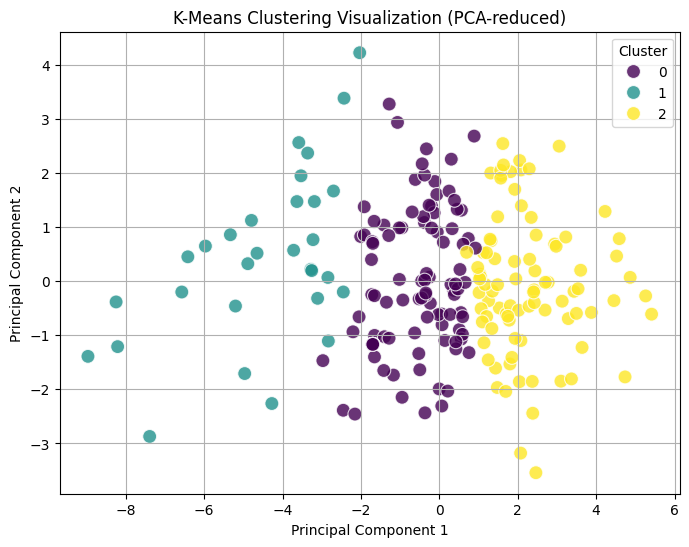

<Figure size 640x480 with 0 Axes>

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Perform PCA to reduce dimensions to 2 for visualization
pca = PCA(n_components=2)
df_x_pca = pca.fit_transform(df_x_scaled)

# Create a DataFrame for the PCA components and add K-Means cluster labels
df_x_pca_df = pd.DataFrame(data = df_x_pca, columns = ['Principal Component 1', 'Principal Component 2'])
df_x_pca_df['KMeans_Cluster'] = kmeans_labels

# Visualize the K-Means clusters
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='Principal Component 1', y='Principal Component 2',
    hue='KMeans_Cluster',
    palette='viridis',
    data=df_x_pca_df,
    s=100,
    alpha=0.8
)
plt.title('K-Means Clustering Visualization (PCA-reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()
plt.savefig("my_plot.png", dpi=300)

**Working with KMEANS. Mapping CLusters with stress levels by majority voting while comparing with ground truth in master data**

In [ ]:
# Define the mapping from old numerical cluster labels to new descriptive stress levels
cluster_rename_mapping = {0:2, 1:1, 2:3}

# Reset 'KMeans_Cluster' to original numerical labels before mapping
# This ensures we are mapping numerical values (0, 1, 2) from kmeans_labels
master_data_with_kmeans_clusters['KMeans_Cluster'] = kmeans_labels

# Apply the mapping to the 'KMeans_Cluster' column
master_data_with_kmeans_clusters['KMeans_Cluster'] = master_data_with_kmeans_clusters['KMeans_Cluster'].map(cluster_rename_mapping)

print("Master Data with Descriptive K-Means Cluster Labels:")
master_data_with_kmeans_clusters.head()

Master Data with Descriptive K-Means Cluster Labels:


,Age,Gender,Marital status,Current primary role,Highest level of education,Stream/Decipline,Type of institution,Living arrangement,Do you currently earn an income?,Approximate monthly household income,...,V10,V11,V12,V13,V14,V15,V16,V17,Target,KMeans_Cluster
0,18-24,Male,Single,Student,Undergraduate,Arts / Humanities,Government / Public,With family,No,Prefer not to say,...,5,5,5,3,5,3,4,1,2,2
1,18-24,Female,Single,Employed (full-time),Undergraduate,Commerce / Management,Private,With family,Yes,"Below ₹20,000",...,4,4,3,4,4,3,4,4,2,2
2,25-34,Female,Married,Employed (full-time),Postgraduate,Engineering / Technology,Private,With family,Yes,"₹50,001–₹1,00,000",...,4,4,2,4,4,4,4,4,2,2
3,25-34,Female,Single,Employed (full-time),Postgraduate,Commerce / Management,Private,With family,Yes,"₹20,000–₹50,000",...,4,4,4,4,4,3,3,4,2,2
4,35-44,Female,Married,Employed (full-time),Postgraduate,Commerce / Management,Private,With family,Yes,"Above ₹1,00,000",...,5,5,3,4,2,2,4,5,3,3


In [ ]:
master_data_with_kmeans_clusters.to_csv('Cluster Predict.csv')

**Feature importance in cluster (Unsupervised). Based in variation in cluster centroid accross features. More difference in centroid value for a feature, more important it is. Cooler to warmer colour tone in the heatmap indicates more importance**

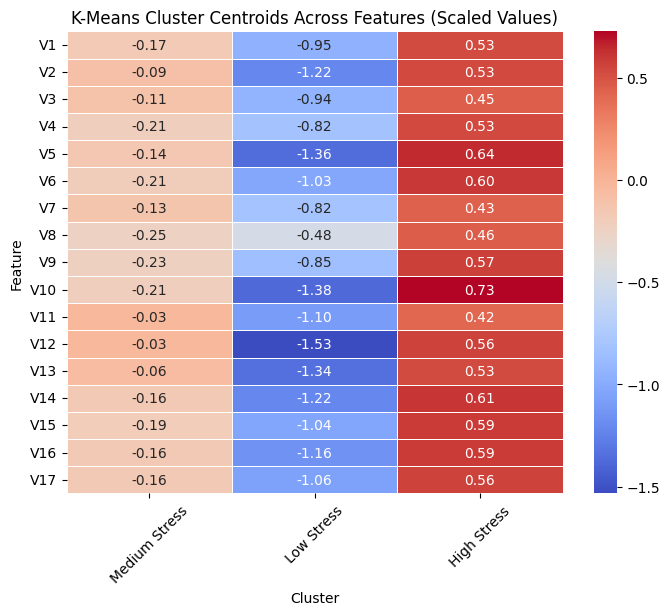

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming df_x, df_x_scaled, and kmeans_model are already defined from previous steps

# Extract K-Means cluster centroids
kmeans_centroids = kmeans_model.cluster_centers_

# Create a DataFrame for the centroids, using original feature names from df_x
kmeans_centroids_df = pd.DataFrame(kmeans_centroids, columns=df_x.columns)

# Make a copy to avoid modifying the original kmeans_centroids_df in place if it's used elsewhere
heatmap_data = kmeans_centroids_df.copy()

# Rename the index to be more descriptive cluster labels
# Assuming the clusters map to stress levels as per the previous mapping (0: Medium, 1: Low, 2: High)
# The order here should match the cluster IDs (0, 1, 2) that kmeans_model.cluster_centers_ returns.
# Based on cell tnuZ3weyk4L_ (cluster_rename_mapping = {0:2, 1:1, 2:3}), this implies:
# original cluster 0 -> new label 2 (Medium Stress)
# original cluster 1 -> new label 1 (Low Stress)
# original cluster 2 -> new label 3 (High Stress)
# So, the centroid index 0 corresponds to 'Medium Stress', 1 to 'Low Stress', and 2 to 'High Stress'
heatmap_data.index = ['Medium Stress', 'Low Stress', 'High Stress']

plt.figure(figsize=(8,6)) # Adjust figure size for readability
sns.heatmap(heatmap_data.T, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('K-Means Cluster Centroids Across Features (Scaled Values)')
plt.xlabel('Cluster')
plt.ylabel('Feature')
plt.xticks(rotation=45)
plt.yticks(rotation=0) # Ensure feature names are readable
plt.show()

**High Variance also indicates importance.**

In [ ]:
import pandas as pd

# Assuming kmeans_centroids_df is already defined

# Calculate the variance of each feature across the clusters
feature_variance = kmeans_centroids_df.var(axis=0)

# Sort features by variance in descending order
sorted_feature_variance = feature_variance.sort_values(ascending=False)

print("Features with highest variance across K-Means clusters (most differentiating):")
display(sorted_feature_variance)

Features with highest variance across K-Means clusters (most differentiating):


,0
V12,1.167200
V10,1.109182
V5,1.014331
V13,0.913962
V14,0.838021
V2,0.789945
V16,0.768257
V6,0.663871
V15,0.661963
V17,0.655435


In [ ]:
df_y.head()

,Target
0,2
1,2
2,2
3,2
4,3


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

xtr,xts,ytr,yts = train_test_split(df_x,df_y, test_size = 0.3, random_state = 42)
rf_model = RandomForestClassifier()
rf_model.fit(xtr,ytr)
y_predict = rf_model.predict(xts)
accuracy = accuracy_score(y_predict,yts)
print(accuracy)

0.6212121212121212


In [ ]:
from sklearn.ensemble import ExtraTreesClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Assuming xtr, xts, ytr, yts are already defined from previous steps

# Extra Trees Classifier
et_model = ExtraTreesClassifier(random_state=42)
et_model.fit(xtr, ytr)
y_pred_et = et_model.predict(xts)
accuracy_et = accuracy_score(y_pred_et, yts)
print(f"Extra Trees Classifier Accuracy: {accuracy_et:.4f}")

# AdaBoost Classifier
ab_model = AdaBoostClassifier(random_state=42)
ab_model.fit(xtr, ytr)
y_pred_ab = ab_model.predict(xts)
accuracy_ab = accuracy_score(y_pred_ab, yts)
print(f"AdaBoost Classifier Accuracy: {accuracy_ab:.4f}")

# Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(xtr, ytr)
y_pred_dt = dt_model.predict(xts)
accuracy_dt = accuracy_score(y_pred_dt, yts)
print(f"Decision Tree Classifier Accuracy: {accuracy_dt:.4f}")

Extra Trees Classifier Accuracy: 0.6061
AdaBoost Classifier Accuracy: 0.5758
Decision Tree Classifier Accuracy: 0.5303


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
import pandas as pd

# Prepare the data
X = df_x # Features
y = df_y.copy() # Target - make a copy to avoid modifying original Series
y = y - 1 # Adjust target labels to be 0-indexed (0, 1, 2 instead of 1, 2, 3)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Initialize models
models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Extra Trees': ExtraTreesClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss') # eval_metric added for multi-class
}

# DataFrame to store results
results = pd.DataFrame(columns=['Accuracy', 'Precision', 'Recall'], index=models.keys())

# Train and evaluate each model
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Calculate metrics. For multi-class, 'weighted' average is often suitable for precision and recall.
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)

    results.loc[name] = [accuracy, precision, recall]

print("\n--- Classification Model Performance for Improving Accuracy Baseline ---")
display(results)

Training Random Forest...
Training Extra Trees...
Training AdaBoost...
Training Decision Tree...
Training XGBoost...

--- Classification Model Performance for Improving Accuracy Baseline ---


,Accuracy,Precision,Recall
Random Forest,0.651515,0.639807,0.651515
Extra Trees,0.69697,0.690355,0.69697
AdaBoost,0.590909,0.588901,0.590909
Decision Tree,0.575758,0.581169,0.575758
XGBoost,0.560606,0.546563,0.560606


In [ ]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

print("Starting K-fold Cross-Validation and Hyperparameter Tuning...")

# Prepare the data (already 0-indexed target from previous steps)
X = df_x # Features
y = df_y.copy() # Target - make a copy to avoid modifying original Series
y = y - 1 # Ensure target labels are 0-indexed (0, 1, 2 instead of 1, 2, 3)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Define models and their parameter grids for tuning
models_and_params = {
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100, 150],
            'max_depth': [None, 10, 20],
            'min_samples_split': [2, 5]
        }
    },
    'Extra Trees': {
        'model': ExtraTreesClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100, 150],
            'max_depth': [None, 10, 20],
            'min_samples_split': [2, 5]
        }
    },
    'AdaBoost': {
        'model': AdaBoostClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100, 150],
            'learning_rate': [0.01, 0.1, 0.5]
        }
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {
            'max_depth': [None, 10, 20],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }
    },
    'XGBoost': {
        'model': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss'),
        'params': {
            'n_estimators': [50, 100, 150],
            'learning_rate': [0.01, 0.1, 0.3],
            'max_depth': [3, 5, 7],
            'subsample': [0.7, 0.9]
        }
    }
}

# DataFrame to store results after tuning
tuned_results = pd.DataFrame(columns=['Best Params', 'Accuracy', 'Precision', 'Recall', 'F1-Score'], index=models_and_params.keys())

# Perform GridSearchCV for each model
for name, mp in models_and_params.items():
    print(f"\n--- Tuning {name} ---")
    grid_search = GridSearchCV(
        estimator=mp['model'],
        param_grid=mp['params'],
        cv=5, # 5-fold cross-validation
        scoring='accuracy', # Optimize for accuracy
        n_jobs=-1, # Use all available CPU cores
        verbose=1
    )

    grid_search.fit(X_train, y_train)

    # Get best estimator and parameters
    best_model = grid_search.best_estimator_
    best_params = grid_search.best_params_

    print(f"Best parameters for {name}: {best_params}")

    # Evaluate best model on the test set
    y_pred = best_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    tuned_results.loc[name] = [best_params, accuracy, precision, recall, f1]

print("\n--- Classification Model Performance After Hyperparameter Tuning ---")
display(tuned_results)

print("K-fold Cross-Validation and Hyperparameter Tuning Complete.")

Starting K-fold Cross-Validation and Hyperparameter Tuning...

--- Tuning Random Forest ---
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters for Random Forest: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}

--- Tuning Extra Trees ---
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters for Extra Trees: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}

--- Tuning AdaBoost ---
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best parameters for AdaBoost: {'learning_rate': 0.5, 'n_estimators': 100}

--- Tuning Decision Tree ---
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters for Decision Tree: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2}

--- Tuning XGBoost ---
Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best parameters for XGBoost: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.7}

--- Classificatio

,Best Params,Accuracy,Precision,Recall,F1-Score
Random Forest,"{'max_depth': None, 'min_samples_split': 5, 'n...",0.712121,0.713671,0.712121,0.688879
Extra Trees,"{'max_depth': 10, 'min_samples_split': 2, 'n_e...",0.742424,0.746442,0.742424,0.727739
AdaBoost,"{'learning_rate': 0.5, 'n_estimators': 100}",0.575758,0.570158,0.575758,0.559202
Decision Tree,"{'max_depth': None, 'min_samples_leaf': 4, 'mi...",0.590909,0.631357,0.590909,0.601894
XGBoost,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",0.651515,0.635885,0.651515,0.637388


K-fold Cross-Validation and Hyperparameter Tuning Complete.


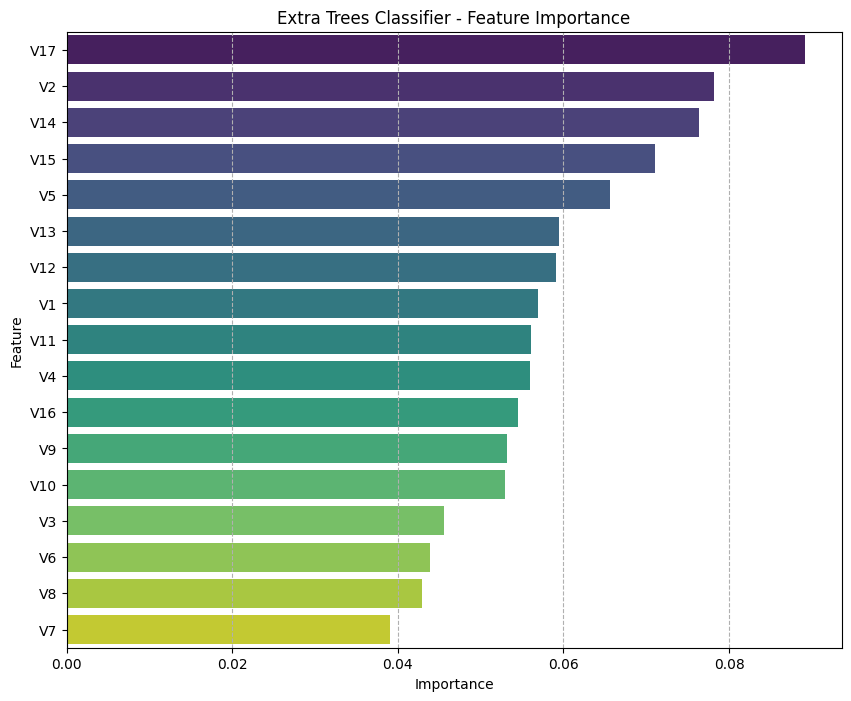

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming et_model is already trained from the previous steps
# and X (df_x) contains the feature names

# Get feature importances from the Extra Trees model
et_feature_importances = et_model.feature_importances_

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': et_feature_importances
})

# Sort features by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Extra Trees Classifier - Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--')
plt.show()

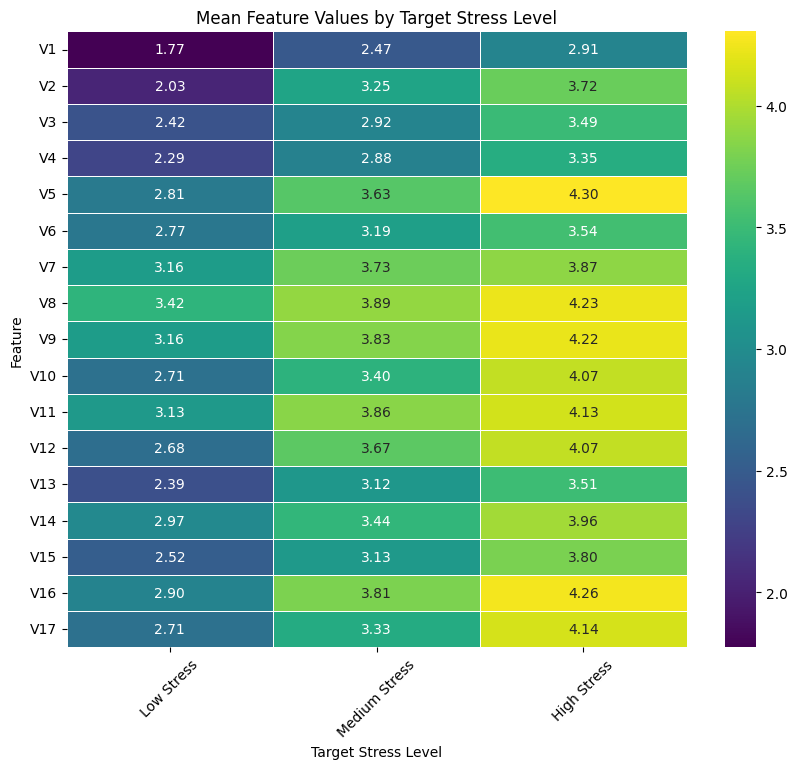

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Combine df_x and the 0-indexed target labels
# The 'y' variable from previous classification steps is already 0-indexed (0, 1, 2)
data_with_target = df_x.copy()
data_with_target['Target'] = y

# Calculate the mean of each feature for each target label
feature_means_by_target = data_with_target.groupby('Target').mean()

# Map the 0-indexed target labels to descriptive names for better readability
# 0 (was 1) -> Low Stress, 1 (was 2) -> Medium Stress, 2 (was 3) -> High Stress
target_label_descriptive_names = {0: 'Low Stress', 1: 'Medium Stress', 2: 'High Stress'}
feature_means_by_target.index = feature_means_by_target.index.map(target_label_descriptive_names)

plt.figure(figsize=(10, 8))
sns.heatmap(feature_means_by_target.T, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
plt.title('Mean Feature Values by Target Stress Level')
plt.xlabel('Target Stress Level')
plt.ylabel('Feature')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()